In [1]:
library(ipumsr)
library(dplyr)
library(tidyr)
library(ggplot2)


Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




**Part 1**

In [2]:
ddi <- read_ipums_ddi("usa_00074.xml")
data <- read_ipums_micro(ddi)

Use of data from IPUMS USA is subject to conditions including that users should cite the data appropriately. Use command `ipums_conditions()` for more details.



In [3]:
data %>% group_by(MORTGAGE = haven::as_factor(MORTGAGE)) %>% summarize(n=n()) %>% 

ERROR: Error in parse(text = input): <text>:2:0: unexpected end of input
1: data %>% group_by(MORTGAGE = haven::as_factor(MORTGAGE)) %>% summarize(n=n()) %>% 
   ^


In [4]:
data %>% group_by(MORTGAGE=haven::as_factor(MORTGAGE)) %>% summarize(n=sum(PERWT)) %>% mutate(pct = n/sum(n))

MORTGAGE,n,pct
<fct>,<dbl>,<dbl>
N/A,107104033,0.346223180
"No, owned free and clear",53211365,0.172010404
"Yes, mortgaged/ deed of trust or similar debt",146806345,0.474564385
"Yes, contract to purchase",2227946,0.007202031


In [5]:
data %>% filter(PERNUM == 1) %>% group_by(MORTGAGE = haven::as_factor(MORTGAGE)) %>% summarize(n= n()) %>% mutate(pct = n/sum(n))

MORTGAGE,n,pct
<fct>,<int>,<dbl>
N/A,426976,0.332619758
"No, owned free and clear",307864,0.239829988
"Yes, mortgaged/ deed of trust or similar debt",541709,0.421998230
"Yes, contract to purchase",7127,0.005552024


In [6]:
data %>% filter(PERNUM == 1) %>% group_by(MORTAGE = haven::as_factor(MORTGAGE)) %>% summarize(n = sum(HHWT)) %>% mutate(PCT = n/sum(n))

MORTAGE,n,PCT
<fct>,<dbl>,<dbl>
N/A,47607067,0.388455433
"No, owned free and clear",24600389,0.200729752
"Yes, mortgaged/ deed of trust or similar debt",49666435,0.405259087
"Yes, contract to purchase",680881,0.005555728


In [7]:
data %>% filter(VALUEH != 0 & VALUEH != 9999999 & PERNUM == 1) %>% group_by(MORTGAGE = haven::as_factor(MORTGAGE)) %>% summarize(VALUEH = weighted.mean(VALUEH, HHWT))

MORTGAGE,VALUEH
<fct>,<dbl>
"No, owned free and clear",219110.3
"Yes, mortgaged/ deed of trust or similar debt",267941.3
"Yes, contract to purchase",144675.2


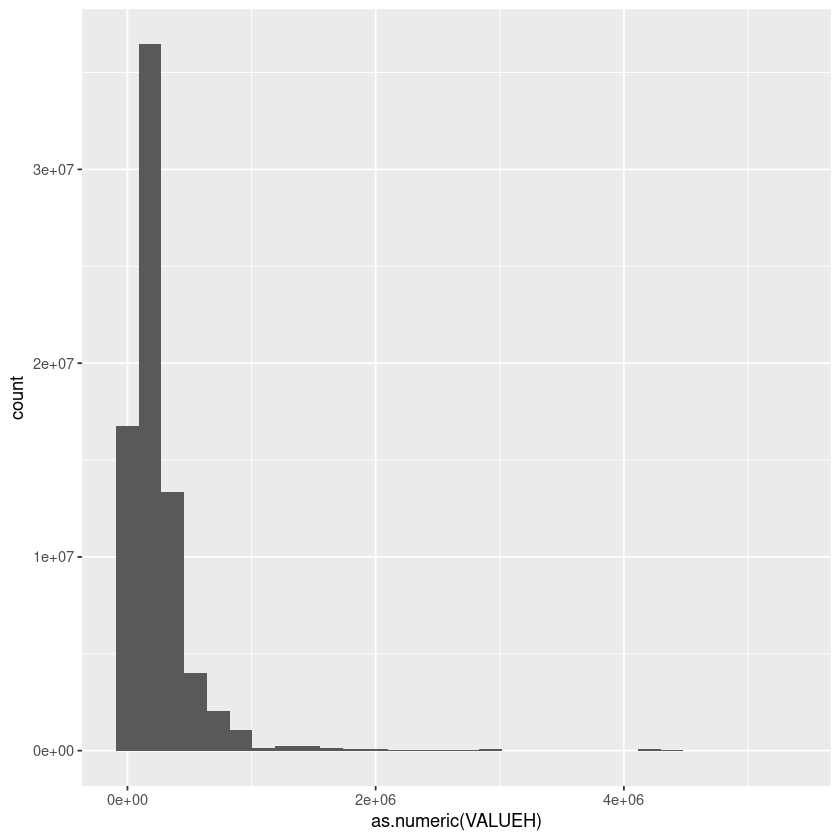

In [8]:
data_summary <- data %>% filter(VALUEH !=0 & VALUEH != 9999999 & PERNUM == 1)
ggplot(data_summary, aes(x = as.numeric(VALUEH), weight = HHWT)) + stat_bin(bins=30)

**Part 2**

In [9]:
data %>% group_by(LANGUAGE = haven::as_factor(LANGUAGE, level = "both")) %>% summarize(n = sum(PERWT)) %>% mutate(pct = n/sum(n)) %>% arrange(desc(n))

LANGUAGE,n,pct
<fct>,<dbl>,<dbl>
[1] English,229753346,0.7426978406
[12] Spanish,36981799,0.1195469086
[0] N/A or blank,20095332,0.0649599231
[43] Chinese,2717534,0.0087846670
[31] Hindi and related,2104371,0.0068025638
[11] French,2098698,0.0067842253
"[54] Filipino, Tagalog",1697559,0.0054875083
[50] Vietnamese,1390472,0.0044948227
[2] German,1222054,0.0039503967


In [10]:
data %>% filter(LANGUAGE == 1) %>% summarize(mom_spanish = weighted.mean(LANGUAGE_MOM == 12, PERWT, na.rm = TRUE), mom_chinese = weighted.mean(LANGUAGE_MOM == 43, PERWT, na.rm = TRUE)) 

mom_spanish,mom_chinese
<dbl>,<dbl>
0.03890631,0.002225844


In [11]:
data %>% filter(haven::as_factor(SEX) == "Male" & AGE < 30) %>% group_by(LANGUAGE = haven::as_factor(LANGUAGE)) %>% summarize(n = sum(PERWT)) %>% mutate(pct = n/sum(n)) %>% arrange(desc(pct))

LANGUAGE,n,pct
<fct>,<dbl>,<dbl>
English,41701183,0.6490096083
N/A or blank,10264433,0.1597488407
Spanish,8615686,0.1340888338
Chinese,459082,0.0071448484
Hindi and related,381566,0.0059384406
French,329330,0.0051254741
Vietnamese,250195,0.0038938694
German,194703,0.0030302286
Arabic,187287,0.0029148109


**Part 3**

In [17]:
ddi <- read_ipums_ddi("usa_00076.xml")
data <- read_ipums_micro(ddi)

Use of data from IPUMS USA is subject to conditions including that users should cite the data appropriately. Use command `ipums_conditions()` for more details.



In [18]:
data %>% filter(PERNUM == 1 & METRO ==2) %>% group_by(YEAR) %>% summarize(own = weighted.mean(OWNERSHP == 1, HHWT))

YEAR,own
<int>,<dbl>
2005,0.7347002
2006,0.6703826
2007,0.6716653
2008,0.6654684
2009,0.6646873
2010,0.6664317


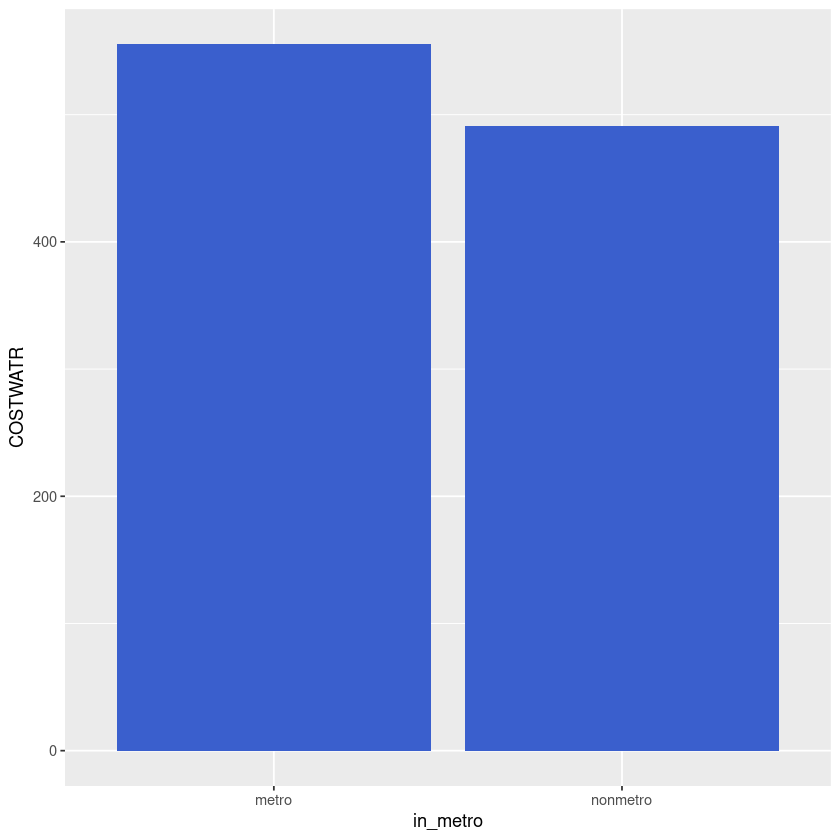

In [21]:
data <- data %>% mutate (in_metro = case_when(METRO == 1 ~ "nonmetro", METRO %in% 2:4 ~ "metro", METRO == 0 ~ NA_character_))
data %>% filter(PERNUM ==1 & YEAR ==2010 & COSTWATR != 0 & COSTWATR < 9990 & !is.na(in_metro)) %>% group_by(in_metro) %>%
    summarize(COSTWATR = weighted.mean(COSTWATR, HHWT)) %>% ggplot(aes(x = in_metro, y = COSTWATR)) + geom_col(fill = "royalblue3")

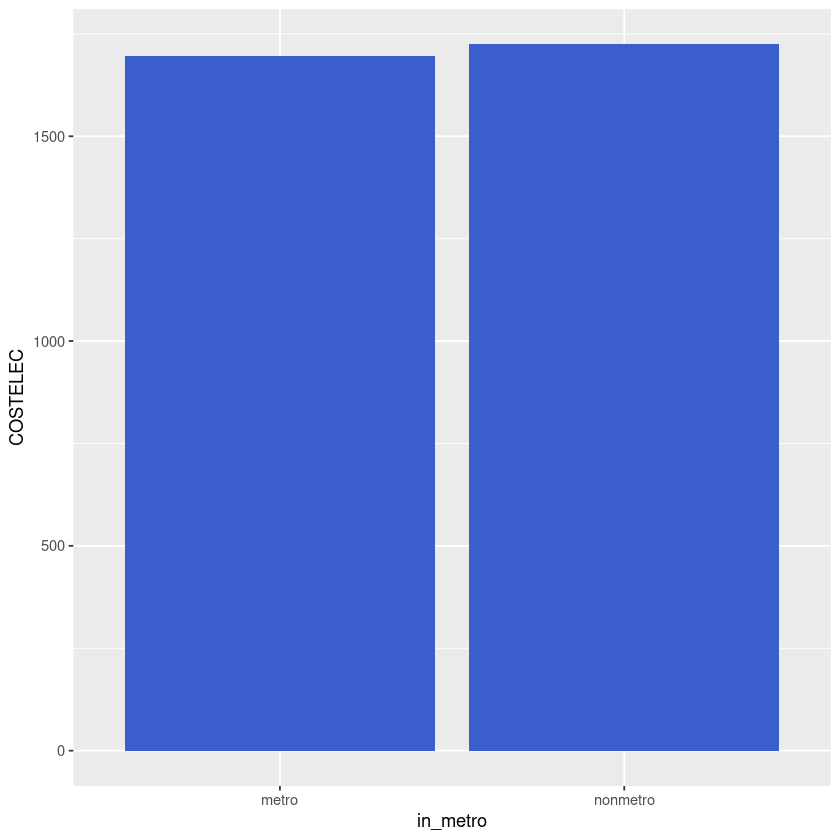

In [24]:
data %>% filter(PERNUM == 1 & YEAR == 2010 & COSTELEC !=0 & COSTELEC < 9990 & !is.na(in_metro)) %>% group_by(in_metro) %>% summarize(COSTELEC = weighted.mean(COSTELEC, HHWT)) %>% ggplot(aes(x = in_metro, y=COSTELEC)) + geom_col(fill="royalblue3")


In [26]:
data_subset <- data %>% filter(PERNUM == 1 & COSTELEC > 0 & COSTELEC < 9990 & ROOMS > 0) %>% select (COSTELEC, ROOMS, HHWT)
wtd_covariance <- cov.wt(data_subset %>% select (COSTELEC, ROOMS), wt = data_subset$HHWT, cor = TRUE)
wtd_covariance$cor

,COSTELEC,ROOMS
COSTELEC,1.0000000,0.2995444
ROOMS,0.2995444,1.0000000


In [27]:
data_summary <- data %>% filter(PERNUM ==1 & COSTGAS != 0 & COSTGAS < 9990 & COSTWATR != 0 & COSTWATR < 9990) %>% filter (UNITSSTR == 3 & ROOMS == 5) %>% group_by(YEAR = YEAR) %>% summarize (COSTGAS = weighted.mean(COSTGAS, HHWT) , COSTWATR = weighted.mean(COSTWATR, HHWT)) %>% gather(key, value, COSTGAS, COSTWATR)


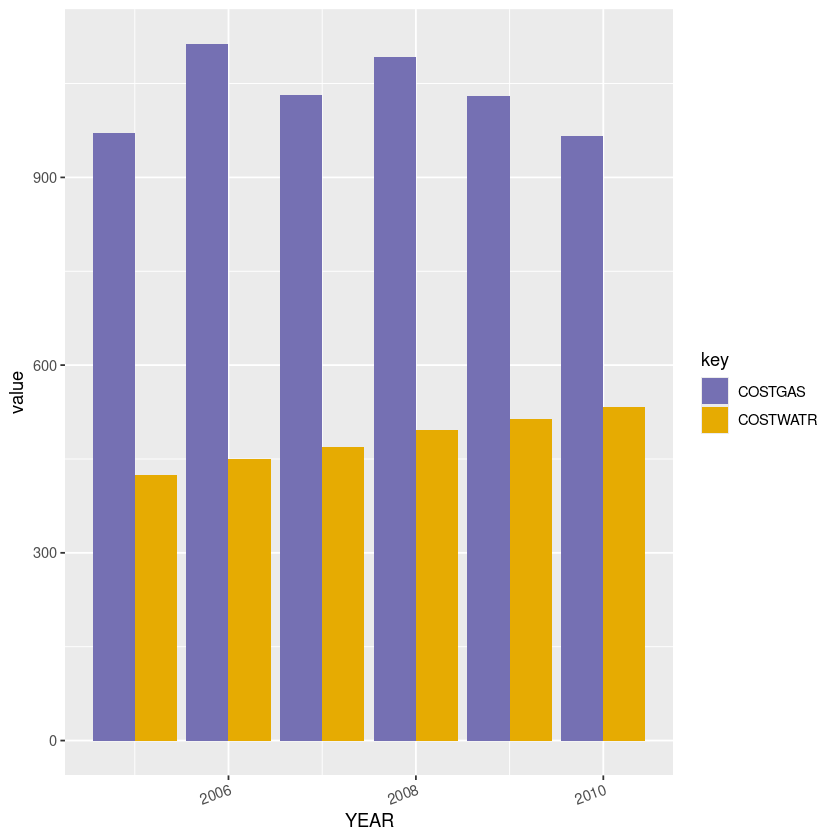

In [28]:
ggplot(data_summary, aes(x = YEAR, y = value, fill = key)) + geom_col(position = "dodge") + theme(axis.text.x = element_text(angle = 20, hjust =1)) + scale_fill_manual(values = c("#7570b3", "#e6ab02"))